In [1]:
from pathlib import Path
import os, sys

# Ensure a common Results/ folder next to Experiments/
cwd = Path.cwd().resolve()
if cwd.name == "Experiments" and (cwd.parent / "Helpers").exists():
    PROJECT_ROOT = cwd.parent
elif (cwd / "Helpers").exists():
    PROJECT_ROOT = cwd
elif (cwd / "MICRO-489_SMLM_tracking" / "Helpers").exists():
    PROJECT_ROOT = cwd / "MICRO-489_SMLM_tracking"
else:
    raise RuntimeError(f"Could not find project root from {cwd}")

OUT_DIR = PROJECT_ROOT / "Results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {OUT_DIR}")

Results directory: C:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking\Results


# Separation Experiment: treat mobile and immobile particles separately

In [2]:
%cd ..
from Helpers.helpersGeneration import *
from Helpers.helpersSimulation import *
from Helpers.helpersTracking import *
from Helpers.helpersStatistics import *
from Helpers.helpersAssignment import *
from Helpers.helpersPlotting import *

c:\Users\armel\OneDrive - epfl.ch\MA2\SMLM\Tracking\MICRO-489_SMLM_tracking


In [3]:
D_list = [
    (0.02, 0.20),
    (0.10, 0.30),
    (2.50, 0.15),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 12,
    "nframes": 20,
    "nposframe": 10,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 650, # nphotons
    "intensity_std": 300,
    "sigma_mean": 1.5, # PSF sigma in pixels
    "sigma_std": 0.5,
}

image_config = {
    "particle_intensity": [650, 300],
    "background_intensity": [150, 50],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
    "use_trajectory_sigma": True,
}

sim = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=None,
).run()

frames = sim.frames
trajectories_HR = sim.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajectories_GT = sim.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajectories_FR = sim.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video = sim.video

In [4]:
animate_video(video, interval=100)

In [5]:
# save video as GIF
save_video_as_gif(video, filename="separated.gif", fps=10)

## Track immobile particles only

In [6]:
# start by tracking only immobile particles, that is within 2 pixels moving distance
localization_results = sim.track(
    mode="localization",
    detection_threshold=None,
    max_distance=2,
    min_length=10,
    max_gap=2,
    stitch_fragments=True,
    stitch_max_gap=4,
    stitch_base_distance=3.0,
    verbose_stitching=True,
)


Auto-computed detection threshold: 317.95 (k=0.7)


In [7]:
static_trajectories_localization = localization_results[0]

8 particles were identified as static.


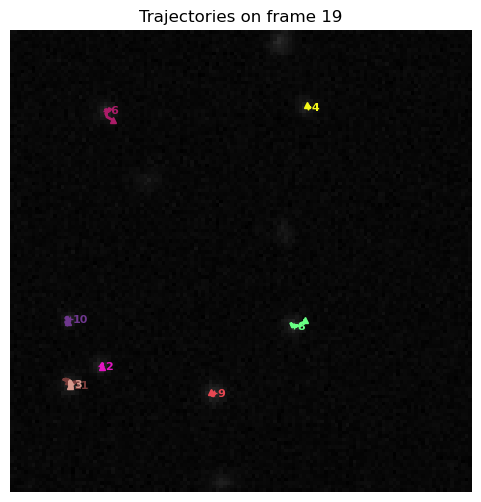

In [8]:
print(f"{len(static_trajectories_localization)} particles were identified as static.")
show_trajectories(frames, static_trajectories_localization, frame_id=simulation_config['nframes']-1, show_id=True)

In [ ]:
print(len(static_trajectories_localization[2].positions))

5


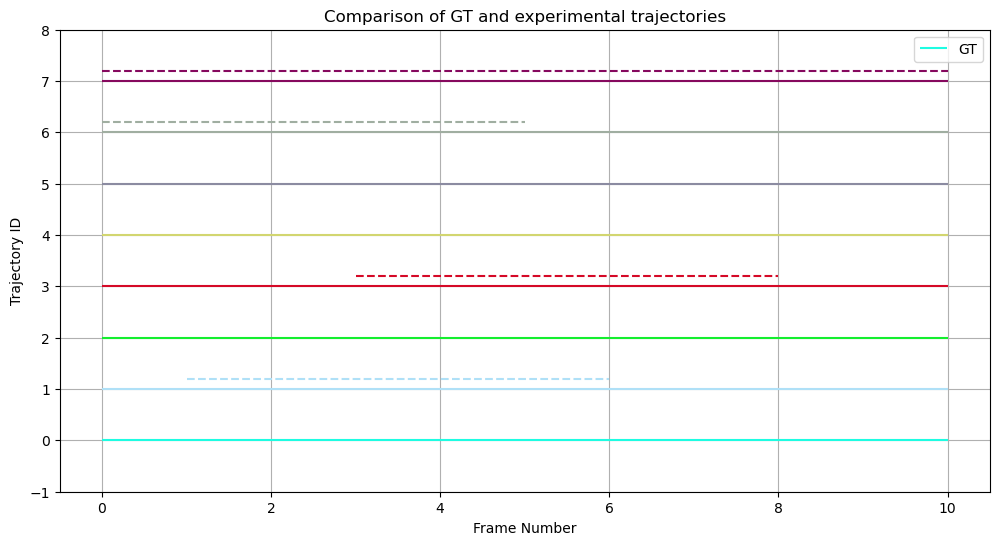

In [ ]:
linear_trajectories_visualizer(static_trajectories_localization, trajectories_GT)

In [ ]:
# # artifically remove the static particles from the video, by replacing them with background noise
# video_aniso_mobile = video_aniso.copy()
# for traj in static_trajectories_localization:
#     frames_aniso_mobile = hide_trajectories(frames, 
#                                                 static_trajectories_localization,
#                                                 bg_mean=image_props["background_intensity"][0], 
#                                                 bg_std=image_props["background_intensity"][1]
#                                             )

In [ ]:
# animate_video(frames_aniso_mobile, interval=100)

### Alternative: detect all peaks, remove statis particles

In [ ]:
peaks_for_tracking = extract_peaks(
                        frames, 
                        mode='localization', 
                        detection_threshold=None, 
                        r_squared_threshold=0.5, 
                        verbose_loc=False, 
                        visualization_loc=False
                     )

[Frame 0] Fitted center for peak at (34, 21): (34.76, 21.44), amplitude 682.73, sigma 1.61
[Frame 0] Fitted center for peak at (47, 115): (47.07, 115.08), amplitude 435.57, sigma 1.33
[Frame 0] Fitted center for peak at (17, 43): (16.16, 43.24), amplitude 480.18, sigma 1.50
[Frame 0] Fitted center for peak at (78, 85): (78.99, 85.62), amplitude 577.19, sigma 1.82
[Frame 0] Fitted center for peak at (81, 16): (81.56, 15.91), amplitude 632.51, sigma 1.95
[Frame 0] Fitted center for peak at (105, 117): (106.18, 116.61), amplitude 466.69, sigma 2.88
[Frame 0] Fitted center for peak at (106, 115): (106.04, 116.29), amplitude 371.33, sigma 2.11
[Frame 0] Fitted center for peak at (32, 50): (31.99, 50.40), amplitude 523.20, sigma 1.91
[Frame 0] Fitted center for peak at (29, 56): (28.77, 55.22), amplitude 333.27, sigma 1.53
[Frame 0] Fitted center for peak at (108, 39): (107.31, 38.82), amplitude 419.30, sigma 2.40
[Frame 0] Fitted center for peak at (105, 121): (105.70, 119.75), amplitude 29

### Approach 1

In [ ]:
# def is_close(p1, p2, tol=3.0):
#     return np.linalg.norm(np.array(p1) - np.array(p2)) < tol

# # Flatten all trajectory positions
# traj_positions = [
#     tuple(pos)
#     for traj in static_trajectories_localization
#     for pos in traj.positions
# ]

# filtered_peaks_for_tracking = []

# for list_idx, peak_list in enumerate(peaks_for_tracking):
#     new_peak_list = []
#     for peak_idx, peak in enumerate(peak_list):
#         peak_pos = peak[0]  # (x, y)

#         # Check if peak matches any trajectory position
#         matched_pos = None
#         for tpos in traj_positions:
#             if is_close(peak_pos, tpos):
#                 matched_pos = tpos
#                 break

#         if matched_pos is None:
#             new_peak_list.append(peak)
#         else:
#             print(
#                 f"[Frame {list_idx}] Removed peak {peak_pos} matching static {matched_pos}"
#             )

#     filtered_peaks_for_tracking.append(new_peak_list)


### Approach 2

In [ ]:
# another more cautious approach: for each static traj position, given its frame, find the closest localized peak and actually remove it such that 
# all static positions are rmoved. keep a certain tolerance threshold as some peaks could overlap or be undetected in peaks_for_tracking.

mobile_peaks_for_tracking = copy.deepcopy(peaks_for_tracking)

for traj in static_trajectories_localization:
    start = traj.start_frame
    end = traj.end_frame
    length = end - start + 1
    positions = traj.positions
    removed_count = 0

    for i in range(length):
        frame_id = start + i
        traj_pos = positions[i]

        peak_list = mobile_peaks_for_tracking[frame_id]

        closest_peak_idx = None
        closest_peak_dist = float('inf')

        # Find closest peak
        for idx, peak in enumerate(peak_list):
            peak_pos = peak[0]
            dist = np.linalg.norm(np.array(peak_pos) - np.array(traj_pos))
            if dist < closest_peak_dist:
                closest_peak_dist = dist
                closest_peak_idx = idx

        # Remove if within tolerance
        if closest_peak_dist < 5.0:
            removed_peak = peak_list.pop(closest_peak_idx)
            print(
                f"[Frame {frame_id}] Removed peak {removed_peak[0]} "
                f"closest to static position {traj_pos}"
            )
            removed_count += 1

    print(
        f"Removed {removed_count} peaks from static trajectory {traj.id} "
        f"(length {length}, frames {start}–{end})"
    )


[Frame 0] Removed peak (47.07463643991897, 115.08475108878574) closest to static position (47.07463643991897, 115.08475108878574)
[Frame 1] Removed peak (46.5419202108286, 115.95390413247101) closest to static position (46.5419202108286, 115.95390413247101)
[Frame 2] Removed peak (46.96761765239978, 117.30756522288966) closest to static position (46.96761765239978, 117.30756522288966)
[Frame 3] Removed peak (45.74362079830393, 118.37644288562674) closest to static position (45.74362079830393, 118.37644288562674)
[Frame 4] Removed peak (45.1517762718252, 118.40559976528773) closest to static position (45.1517762718252, 118.40559976528773)
Removed 5 peaks from static trajectory 6 (length 5, frames 0–4)
[Frame 0] Removed peak (81.56480089358641, 15.914273745712308) closest to static position (81.56480089358641, 15.914273745712308)
[Frame 1] Removed peak (81.12289063447648, 16.07958569220541) closest to static position (81.12289063447648, 16.07958569220541)
[Frame 2] Removed peak (80.93514

### Approach 3

In [ ]:
# # another approach: remove all peaks that are within a certain distance from any static trajectory position, regardless of frame. this is more aggressive but ensures all static positions are removed.
# # calculate cog of static trajectories
# static_cogs = []
# for traj in static_trajectories_localization:
#     positions = traj.positions
#     cog = np.mean(positions, axis=0)
#     static_cogs.append(cog)

# # find closest peak to each cog in all frames and remove it if within tolerance
# mobile_peaks_for_tracking = peaks_for_tracking.copy()
# for cog in static_cogs:
#     for frame_id, peak_list in enumerate(mobile_peaks_for_tracking):
#         closest_peak_idx = None
#         closest_peak_dist = float('inf')
#         for idx, peak in enumerate(peak_list):
#             peak_pos = peak[0]  # (x, y)
#             dist = np.linalg.norm(np.array(peak_pos) - np.array(cog))
#             if dist < closest_peak_dist:
#                 closest_peak_dist = dist
#                 closest_peak_idx = idx
        
#         if closest_peak_dist < 10.0:  # tolerance threshold
#             removed_peak = peak_list.pop(closest_peak_idx)
#             print(
#                 f"[Frame {frame_id}] Removed peak {removed_peak[0]} corresponding to static cog {cog})"
#             )

[Frame 5] Removed peak (47.7210430279908, 117.64844106625866) corresponding to static cog [ 46.29591427 117.02565262])
[Frame 6] Removed peak (48.93232666693837, 116.92934743986038) corresponding to static cog [ 46.29591427 117.02565262])
[Frame 7] Removed peak (50.44493815987804, 113.52937813544743) corresponding to static cog [ 46.29591427 117.02565262])
[Frame 8] Removed peak (48.4978257909861, 112.96705472516145) corresponding to static cog [ 46.29591427 117.02565262])
[Frame 9] Removed peak (49.666678729732546, 115.49124910938282) corresponding to static cog [ 46.29591427 117.02565262])
[Frame 8] Removed peak (79.45451439738403, 17.023982065002002) corresponding to static cog [80.50197921 16.82260433])
[Frame 0] Removed peak (28.77098399559192, 55.22340395255056) corresponding to static cog [33.56961067 60.79414049])
[Frame 8] Removed peak (32.86750833901576, 57.99445050425446) corresponding to static cog [33.56961067 60.79414049])
[Frame 9] Removed peak (30.566515087466573, 60.50

In [ ]:
# # track with regular pipeline on the remaining mobile trajectories
# mobile_trajectories_localization, cost_peak2peak, mobile_assignment_localization, cost_traj2traj = track(
#     frames_aniso_mobile,
#     trajectories_GT,
#     detection_threshold=intensity_mean - 0.8 * intensity_std,
#     max_distance=10, # back to normal param
#     min_length=5,
#     r_squared_threshold=0.7,
#     algo_peak2peak="hungarian",
#     algo_traj2traj="hungarian",
#     cost_function=None,
#     verbose_loc=False,
#     visualization_loc=False,
#     verbose_assignment=False,
# )


[Frame 0] Fitted center for peak at (76, 32): (75.84, 32.59), amplitude 703.25, sigma 1.40
[Frame 0] Fitted center for peak at (33, 23): (32.99, 22.72), amplitude 695.92, sigma 1.72
[Frame 0] Fitted center for peak at (48, 105): (47.87, 104.74), amplitude 796.96, sigma 1.90
[Frame 0] Fitted center for peak at (94, 64): (93.88, 62.90), amplitude 558.76, sigma 2.31
[Frame 0] Fitted center for peak at (86, 100): (86.36, 100.33), amplitude 522.14, sigma 2.28
[Frame 1] Fitted center for peak at (49, 105): (48.99, 105.26), amplitude 862.37, sigma 1.95
[Frame 1] Fitted center for peak at (77, 32): (77.03, 31.15), amplitude 548.71, sigma 1.93
[Frame 1] Fitted center for peak at (84, 101): (84.17, 100.60), amplitude 516.84, sigma 1.55
[Frame 1] Fitted center for peak at (35, 24): (34.89, 23.89), amplitude 581.44, sigma 2.17
[Frame 1] Fitted center for peak at (102, 62): (101.66, 61.48), amplitude 441.14, sigma 1.87
[Frame 1] Poor fit for peak at (34, 109): R-squared = 0.667 (below threshold of 

In [ ]:
print(f"{len(mobile_trajectories_localization)} particles were identified as mobile.")

10 particles were identified as mobile.


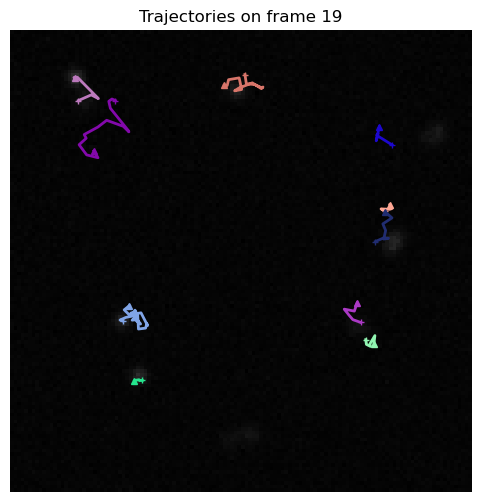

In [ ]:
show_trajectories(frames_aniso_mobile, mobile_trajectories_localization, frame_id=nframes-1)

## Comparison between with regular and separated pipelines

Create trajs: use the same in both pipelines for comparison

In [ ]:
D_list = [
    (0.10, 0.30),
    (0.50, 0.10),
    (1.50, 0.15),
    (3.50, 0.10),
    (4.00, 0.15),
    (5.00, 0.20),
]

simulation_config = {
    "nparticles": 10,
    "nframes": 20,
    "nposframe": 5,
    "D_list": D_list,
    "dt": 1.0,
    "anisotropy_ratio_range": (1.0, 1.0),
    "theta_range": (np.deg2rad(30), np.deg2rad(30)),
    "frame_size": (128, 128),
    "intensity_mean": 800, # nphotons
    "intensity_std": 100,
}

image_config = {
    "particle_intensity": [800, 100],
    "background_intensity": [100, 30],
    "poisson_noise": 100,
    "output_size": 128,
    "upsampling_factor": 5,
    "resolution": 100e-9,
    "trajectory_unit": -1,
    "invert_y": True,
}

sim_reg = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42,
).run()

frames_reg = sim_reg.frames
trajs_HR_reg = sim_reg.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajs_GT_reg = sim_reg.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajs_FR_reg = sim_reg.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video_reg = sim_reg.video

sim_sep = Simulator(
    simulation_config=simulation_config,
    image_config=image_config,
    seed=42, # same seed to have same trajectories!
).run()

frames_sep = sim_sep.frames
trajs_HR_sep = sim_sep.trajectories_HR # high-resolution trajectories with size nframes x nposframe
trajs_GT_sep = sim_sep.trajectories_GT # Ground-Truth, low-resolution trajectories with size nframes
trajs_FR_sep = sim_sep.trajectories_FR # low-resolution trajectories with size nframes, with diffusion data computed from GT
video_sep = sim_sep.video

In [ ]:
# define custom cost function for peak-to-peak assignment: separate weights between distance, intensity and sigma
peak2peak_cost = PeakToPeak(
    terms={
        "distance": DistanceTerm(weight=0.5, norm=image_config["output_size"]/10),
        "intensity": IntensityTerm(weight=0.5, norm=image_config["particle_intensity"][0]+image_config["particle_intensity"][1]),
    }
)

# define custom cost function for trajectory-to-trajectory assignment: fully weighted on distance between trajectories
traj_cost = TrajToTraj(
    terms={
        "position": MeanPositionDistanceTerm(weight=0.8, norm=1.0),
        "length": LengthDifferenceTerm(weight=0.1, norm=10),
        "start_frame": StartFrameDifferenceTerm(weight=0.1, norm=5),
    }
)

Case 1: Regular tracking

In [ ]:
# tracking all particles within sensible max distance
loc_results_reg = sim_reg.track(
    mode="localization",
    detection_threshold=400,
    max_distance=10, # all trajs
    min_length=5,
    cost_func_peak2peak=peak2peak_cost,
    cost_func_traj2traj=traj_cost
)

trajs_loc_reg = loc_results_reg[0]

[Frame 0] Fitted center for peak at (43, 90): (42.65, 89.64), amplitude 686.13, sigma 1.27
[Frame 0] Fitted center for peak at (37, 73): (36.85, 73.06), amplitude 693.32, sigma 1.19
[Frame 0] Fitted center for peak at (109, 15): (108.80, 15.47), amplitude 586.55, sigma 1.48
[Frame 0] Fitted center for peak at (110, 80): (109.89, 80.53), amplitude 835.26, sigma 1.82
[Frame 0] Fitted center for peak at (55, 111): (55.42, 110.38), amplitude 658.10, sigma 1.28
[Frame 0] Fitted center for peak at (27, 51): (27.81, 50.90), amplitude 599.18, sigma 1.86
[Frame 0] Fitted center for peak at (29, 51): (27.63, 50.99), amplitude 466.27, sigma 1.61
[Frame 0] Fitted center for peak at (55, 16): (54.21, 15.23), amplitude 569.54, sigma 2.51
[Frame 0] Fitted center for peak at (108, 97): (108.89, 97.49), amplitude 530.00, sigma 2.47
[Frame 0] Fitted center for peak at (85, 94): (83.97, 93.45), amplitude 310.87, sigma 1.56
[Frame 0] Fitted center for peak at (83, 94): (83.86, 93.16), amplitude 501.59, si

Case 2: Separated tracking

In [ ]:
# tracking only immobile particles, that is within 2 pixels moving distance
# loc_results_sep = sim_sep.track(
#     mode="localization",
#     detection_threshold=400,
#     max_distance=2, # only static
#     min_length=5,
#     cost_func_peak2peak=peak2peak_cost,
#     cost_func_traj2traj=traj_cost
# )
# print(f"Found {len(loc_results_sep[0])} static particles.")

Removed 20 peaks from static trajectory 9 (length 20, frames 0–19)
Removed 16 peaks from static trajectory 11 (length 16, frames 0–19)
Removed 12 peaks from static trajectory 4 (length 12, frames 0–12)
Removed 18 peaks from static trajectory 8 (length 18, frames 0–19)
Removed 17 peaks from static trajectory 10 (length 17, frames 0–19)
Removed 17 peaks from static trajectory 6 (length 17, frames 2–19)
Removed 13 peaks from static trajectory 2 (length 13, frames 7–19)
Removed 10 peaks from static trajectory 3 (length 10, frames 8–18)


NameError: name 'trajs_GT_sep' is not defined

In [11]:
loc_results_sep = localization_results
frames_sep = frames
trajs_GT_sep = trajectories_GT

static_trajs_loc_sep = loc_results_sep[0]

In [12]:
# now extract all peaks
peaks_for_tracking_sep = extract_peaks(
                        frames_sep, 
                        mode='localization', 
                        detection_threshold=None, 
                        verbose_loc=False, 
                        visualization_loc=False
                     )

In [13]:
# remove peaks corresponding to static trajectories
mobile_peaks_for_tracking_sep = remove_static_peaks(peaks_for_tracking_sep, static_trajs_loc_sep, tolerance=5.0, verbose=True)

Removed 20 peaks from static trajectory 9 (length 20, frames 0–19)
Removed 16 peaks from static trajectory 11 (length 16, frames 0–19)
Removed 12 peaks from static trajectory 4 (length 12, frames 0–12)
Removed 18 peaks from static trajectory 8 (length 18, frames 0–19)
Removed 17 peaks from static trajectory 10 (length 17, frames 0–19)
Removed 17 peaks from static trajectory 6 (length 17, frames 2–19)
Removed 13 peaks from static trajectory 2 (length 13, frames 7–19)
Removed 10 peaks from static trajectory 3 (length 10, frames 8–18)


In [17]:
# visualize mobile peaks on video with red crosses
def animate_video_with_peaks(
    video,
    peaks,
    interval=100,
    cmap="gray",
    vmin=0,
    vmax=1000,
    marker_size=55,
):
    """
    Animate a video and overlay detections as red crosses.

    peaks[frame] is expected to contain detections whose first element is
    the position in image coordinates as (row, col).
    """
    fig, ax = plt.subplots(figsize=(5, 5))

    if vmin is None:
        vmin = video.min()
    if vmax is None:
        vmax = video.max()

    im = ax.imshow(video[0], cmap=cmap, vmin=vmin, vmax=vmax, animated=True)
    scat = ax.scatter(
        [],
        [],
        s=marker_size,
        c="red",
        marker="x",
        linewidths=1.5,
        animated=True,
    )
    title = ax.set_title("Frame 0")
    ax.axis("off")

    def update(frame):
        im.set_array(video[frame])

        peak_positions = np.array([peak[0] for peak in peaks[frame]], dtype=float)
        if len(peak_positions) > 0:
            rows = peak_positions[:, 0]
            cols = peak_positions[:, 1]
            scat.set_offsets(np.c_[cols, rows])
        else:
            scat.set_offsets(np.empty((0, 2)))

        title.set_text(f"Frame {frame}")
        return [im, scat, title]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(video),
        interval=interval,
        blit=True,
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())

animate_video_with_peaks(frames_sep, peaks_for_tracking_sep, interval=100)

In [16]:
save_video_as_gif(frames_sep, filename="mobile_peaks.gif", fps=10)

In [20]:
# track with regular pipeline on the remaining mobile trajectories
trajs_loc_sep, cost_peak2peak_sep, assignment_output_sep, cost_traj2traj_sep = track_from_peaks(mobile_peaks_for_tracking_sep,
                                                                                                            trajs_GT_sep, 
                                                                                                            max_distance=10, 
                                                                                                            min_length=5, 
                                                                                                            algo_peak2peak="hungarian", 
                                                                                                            cost_func_peak2peak=None, 
                                                                                                            algo_traj2traj="hungarian", 
                                                                                                            cost_func_traj2traj=None, 
                                                                                                            verbose_assignment=False)


Tracking 319 peaks across 20 frames...


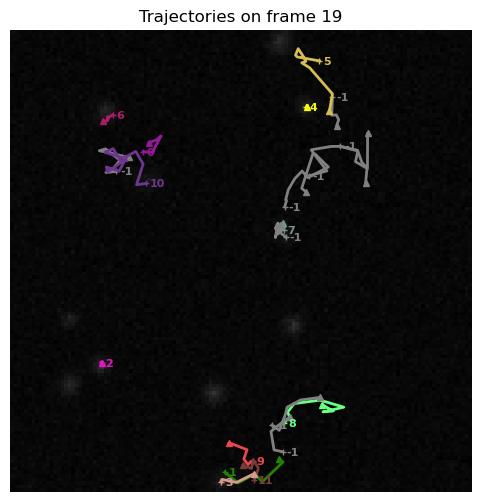

In [21]:
show_trajectories(frames_sep, trajs_loc_sep, frame_id=simulation_config['nframes']-1, show_id=True)

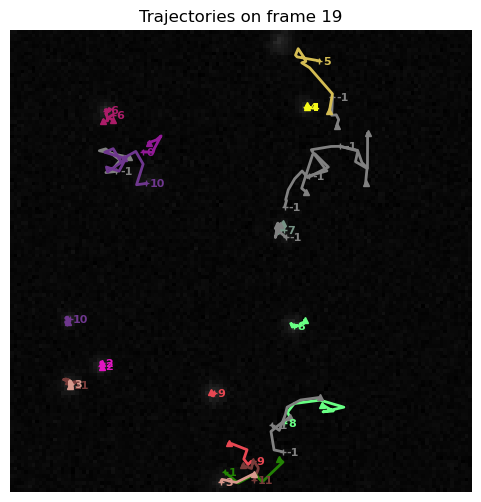

In [22]:
# add back the static trajectories to the mobile ones to have the full set of trajectories for evaluation
trajs_loc_sep += static_trajs_loc_sep
show_trajectories(frames_sep, trajs_loc_sep, frame_id=simulation_config['nframes']-1, show_id=True)

In [ ]:
trajs_loc_sep, min_cost, assignment = assign_trajectories(trajs_loc_sep, trajs_GT_sep, cost_function = traj_cost, verbose=True)

Cost matrix:
[[13.21025276 18.24872971 65.68492126  1.04547858 73.03586578 33.34674072
  17.94226265 60.44200897 51.10640335 46.98249054]
 [73.44445038 83.2095871  54.40441895 70.15438843  1.54635167 80.01744843
  67.51690674 48.89999008 44.11899948 72.94970703]
 [20.58788872 29.77621651 50.99205017 30.10482025 81.37667847  1.2846607
  50.27234268 49.24184036 74.60694122 28.45292854]
 [33.4642601  32.12070847 79.68170929 24.61838913 67.98091888 53.83286667
   1.18763769 73.76641846 31.81328773 74.65474701]
 [56.32239914 60.3147583  78.35438538 48.88893509 44.88271713 73.31282806
  31.84889221 71.56109619  1.36956823 83.7973938 ]
 [58.87723541 75.04504395  2.41196847 65.03736877 54.26847839 52.28824234
  78.02306366  8.23254204 76.3126297  29.07769394]
 [39.85096359 53.71981812 29.01730537 49.51714325 71.54572296 26.67996788
  66.40421295 29.00397873 80.10126495  1.49777555]
 [14.26632977  1.98497796 72.86112213 14.47546196 83.61481476 29.52487373
  27.78707695 68.15950012 64.11281586 5

Compare the two cases

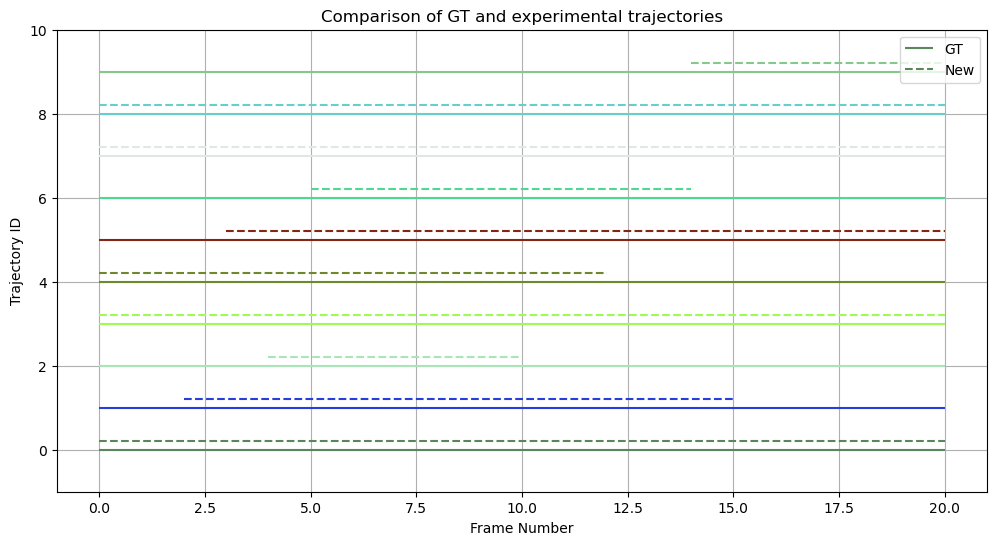

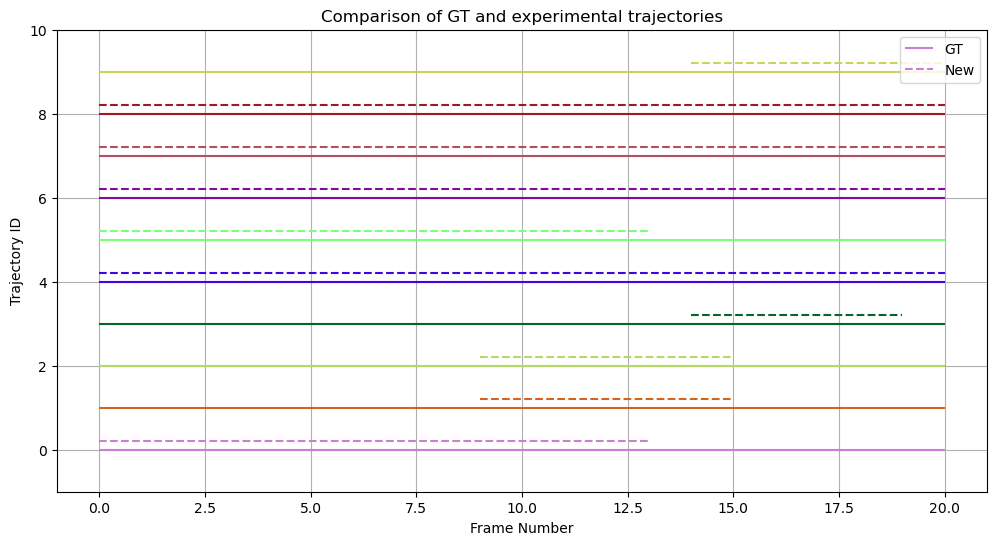

In [ ]:
# first overview: chec num and length of trajectories to see if the tracking sensibly improved
linear_trajectories_visualizer(trajs_loc_reg, trajs_GT_reg)
linear_trajectories_visualizer(trajs_loc_sep, trajs_GT_sep)

In [ ]:
animate_video(video_reg, interval=100)